In [30]:
# 1 Create a simple neural network using Keras to classify handwritten digits from the MNIST dataset, then experiment by changing the number of layers and neurons in your model to see how accuracy changes.<br><br><em><strong>Hint:</strong> Start with one hidden layer, then try adding another, and vary the number of neurons (e.g., 32, 64, 128).</em>

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import time
import matplotlib.pyplot as plt
import keras_tuner as kt

In [31]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

In [32]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

In [33]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [34]:
history = model.fit(X_train, y_train, epochs=5,validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9008 - loss: 0.3564 - val_accuracy: 0.9389 - val_loss: 0.2118
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9464 - loss: 0.1893 - val_accuracy: 0.9523 - val_loss: 0.1624
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9567 - loss: 0.1497 - val_accuracy: 0.9592 - val_loss: 0.1398
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9632 - loss: 0.1265 - val_accuracy: 0.9607 - val_loss: 0.1284
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9673 - loss: 0.1104 - val_accuracy: 0.9654 - val_loss: 0.1191


In [35]:
print("Validation Accuracy:",history.history['val_accuracy'][-1])

Validation Accuracy: 0.965399980545044


In [36]:
# 2 Train your MNIST model using different batch sizes (e.g., 16, 32, 64) and epochs (e.g., 5, 10, 20), and record how the training time and validation accuracy change for each combination.


batch_sizes = [16, 32, 64]
epochs_list = [5, 10, 20]

for batch_size in batch_sizes:
    for epochs in epochs_list:

        model = Sequential([
            Flatten(input_shape=(28, 28)),
            Dense(64, activation='relu'),
            Dense(10, activation='softmax')
        ])

        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        start = time.time()

        history = model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_test, y_test),
            verbose=0
        )

        end = time.time()

        print(
            f"Batch Size={batch_size}, "
            f"Epochs={epochs}, "
            f"Time={end-start:.2f}s, "
            f"Val Accuracy={history.history['val_accuracy'][-1]:.4f}"
        )

Batch Size=16, Epochs=5, Time=24.21s, Val Accuracy=0.9747
Batch Size=16, Epochs=10, Time=44.61s, Val Accuracy=0.9738
Batch Size=16, Epochs=20, Time=83.26s, Val Accuracy=0.9769
Batch Size=32, Epochs=5, Time=11.23s, Val Accuracy=0.9753
Batch Size=32, Epochs=10, Time=20.54s, Val Accuracy=0.9747
Batch Size=32, Epochs=20, Time=42.13s, Val Accuracy=0.9755
Batch Size=64, Epochs=5, Time=7.86s, Val Accuracy=0.9711
Batch Size=64, Epochs=10, Time=13.06s, Val Accuracy=0.9743
Batch Size=64, Epochs=20, Time=27.42s, Val Accuracy=0.9765


In [37]:
# 3 Modify your Keras model to use three different optimizers (SGD, Adam, RMSprop) and compare the results by plotting training and validation loss for each optimizer.
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0
optimizers = ['sgd', 'adam', 'rmsprop']
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [38]:
for opt in optimizers:
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

In [39]:
model.compile(optimizer=opt,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [40]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=0
    )

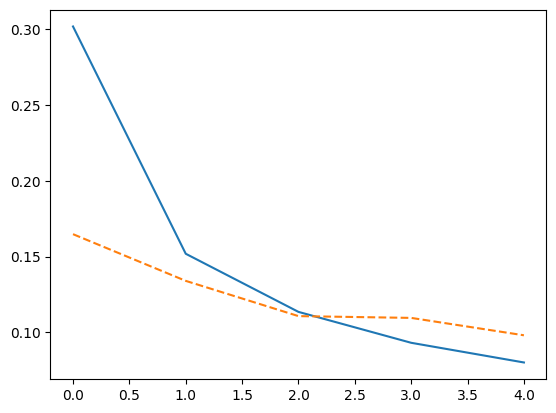

In [41]:
plt.plot(history.history['loss'], label=f'{opt} Train')
plt.plot(history.history['val_loss'], '--', label=f'{opt} Val')


In [42]:
# 4
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

initializers = [
    'he_normal',
    'glorot_uniform',
    'random_normal'
]

In [43]:
for init in initializers:
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_initializer=init),
        Dense(10, activation='softmax')
    ])

In [44]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [46]:
start = time.time()

history = model.fit(X_train,y_train,epochs=5,validation_data=(X_test, y_test),verbose=0)

end = time.time()

In [47]:
print(f"\nInitializer: {init}")
print(f"Training Time: {end-start:.2f} sec")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")


Initializer: random_normal
Training Time: 13.58 sec
Validation Accuracy: 0.9782
